# Mini Project: Student Performance Prediction
**Name:** Rohit Kumar Gupta
**Goal:** Predict whether a student will **Pass** or **Fail** using Study Hours, Attendance, Previous Marks and Assignment Score.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the dataset using Pandas

In [2]:
df = pd.read_csv("student_performance.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 6)


,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Result
0,S001,7.9,84.0,82.0,65.0,Pass
1,S002,4.7,69.0,69.0,82.0,Pass
2,S003,8.7,75.0,79.0,77.0,Pass
3,S004,7.1,73.0,NaN,45.0,Pass
4,S005,1.4,80.0,59.0,74.0,Fail


## 3. Clean the data

In [3]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Student_ID          0
Study_Hours         6
Attendance          8
Previous_Marks      5
Assignment_Score    7
Result              0
dtype: int64


In [4]:
# fill missing values with column mean
for col in ["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]:
    df[col] = df[col].fillna(df[col].mean())

# also check duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after cleaning:
Student_ID          0
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Result              0
dtype: int64


A quick look at the data to understand it better:

In [5]:
df.describe()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score
count,200.000000,200.000000,200.000000,200.000000
mean,5.130928,74.666667,65.348718,69.191710
std,2.644530,13.575893,16.386397,15.298029
min,0.600000,39.000000,20.000000,29.000000
25%,2.875000,65.750000,55.000000,58.750000
50%,5.100000,74.666667,66.000000,69.191710
75%,7.400000,83.000000,75.000000,79.250000
max,9.900000,100.000000,100.000000,100.000000


In [6]:
# average of each feature for Pass and Fail students
df.groupby("Result")[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]].mean().round(2)

,Study_Hours,Attendance,Previous_Marks,Assignment_Score
Result,,,,
Fail,2.93,70.61,55.76,64.19
Pass,6.45,77.10,71.10,72.19


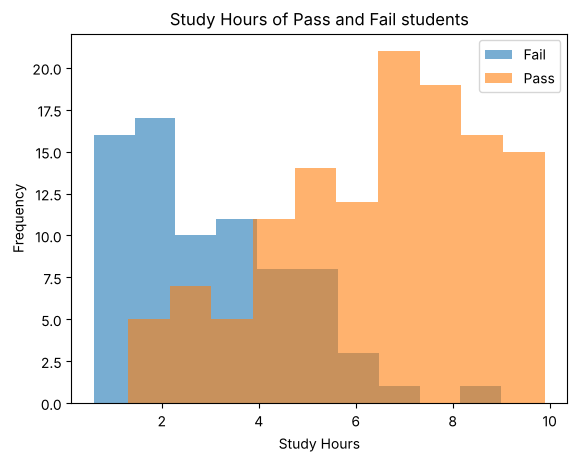

In [7]:
df.groupby("Result")["Study_Hours"].plot(kind="hist", alpha=0.6, legend=True, bins=10)
plt.title("Study Hours of Pass and Fail students")
plt.xlabel("Study Hours")
plt.show()

## 4. Select features and target
Features: Study_Hours, Attendance, Previous_Marks, Assignment_Score
Target: Result (Fail = 0, Pass = 1)

In [8]:
features = ["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]
X = df[features]
y = df["Result"].map({"Fail": 0, "Pass": 1})

print(X.shape, y.shape)
print(y.value_counts())

(200, 4) (200,)
Result
1    125
0     75
Name: count, dtype: int64


## 5. Split into training and testing data (80% / 20%)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 160
Testing samples : 40


## 6. Scale the features

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 7. Train the classification model (Logistic Regression)

In [11]:
model = LogisticRegression()
model.fit(X_train_s, y_train)
print("Model trained")

Model trained


## 8. Make predictions and calculate accuracy

In [12]:
y_pred = model.predict(X_test_s)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Model Accuracy: 85.0 %

Confusion Matrix:
[[12  3]
 [ 3 22]]

              precision    recall  f1-score   support

        Fail       0.80      0.80      0.80        15
        Pass       0.88      0.88      0.88        25

    accuracy                           0.85        40
   macro avg       0.84      0.84      0.84        40
weighted avg       0.85      0.85      0.85        40



In [13]:
# compare some actual and predicted values
compare = X_test.copy()
compare["Actual"] = y_test.map({0: "Fail", 1: "Pass"})
compare["Predicted"] = pd.Series(y_pred, index=y_test.index).map({0: "Fail", 1: "Pass"})
compare.head(10)

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Actual,Predicted
171,5.400000,63.0,56.0,62.0,Fail,Pass
35,2.300000,67.0,70.0,100.0,Pass,Pass
21,3.900000,94.0,86.0,73.0,Pass,Pass
141,5.130928,79.0,85.0,82.0,Pass,Pass
10,4.000000,63.0,63.0,80.0,Fail,Pass
83,2.100000,79.0,100.0,65.0,Pass,Pass
97,1.300000,39.0,69.0,33.0,Fail,Fail
136,9.600000,65.0,64.0,83.0,Pass,Pass
185,6.800000,93.0,50.0,71.0,Pass,Pass
192,1.700000,79.0,66.0,50.0,Fail,Fail


## 9. Test the model with new student inputs
I wrote a small function that takes the details of a new student, scales them with the same scaler, and predicts Pass or Fail.

In [14]:
def predict_student(study_hours, attendance, previous_marks, assignment_score):
    new_data = pd.DataFrame([[study_hours, attendance, previous_marks, assignment_score]],
                            columns=features)
    new_scaled = scaler.transform(new_data)
    result = model.predict(new_scaled)[0]
    prob = model.predict_proba(new_scaled)[0][1]
    label = "PASS" if result == 1 else "FAIL"

    print("Study Hours     :", study_hours)
    print("Attendance      :", str(attendance) + "%")
    print("Previous Marks  :", previous_marks)
    print("Assignment Score:", assignment_score)
    print("Prediction      :", label, "(chance of passing = " + str(round(prob * 100, 1)) + "%)")
    print("-" * 40)
    return label

In [15]:
# Student 1 (example from the task)
predict_student(6, 85, 72, 70)

# Student 2 - studies less, low attendance
predict_student(1.5, 50, 40, 45)

# Student 3 - average student
predict_student(4, 70, 58, 60)

# Student 4 - strong student
predict_student(8.5, 92, 85, 88)

Study Hours     : 6
Attendance      : 85%
Previous Marks  : 72
Assignment Score: 70
Prediction      : PASS (chance of passing = 91.3%)
----------------------------------------
Study Hours     : 1.5
Attendance      : 50%
Previous Marks  : 40
Assignment Score: 45
Prediction      : FAIL (chance of passing = 1.1%)
----------------------------------------
Study Hours     : 4
Attendance      : 70%
Previous Marks  : 58
Assignment Score: 60
Prediction      : FAIL (chance of passing = 34.4%)
----------------------------------------
Study Hours     : 8.5
Attendance      : 92%
Previous Marks  : 85
Assignment Score: 88
Prediction      : PASS (chance of passing = 99.6%)
----------------------------------------


'PASS'

## 10. Observations
- The model reaches good accuracy on the unseen test data.
- Students with more study hours, higher attendance and better previous marks are predicted to pass.
- The dataset is small (200 rows) so results can change a little with a different split.